In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

In [2]:
# =====================================================
# Device
# =====================================================

dev = qml.device("default.qubit", wires=2)

In [3]:
# =====================================================
# Hamiltonian
# =====================================================

coeffs = [1.0, 0.5]

observables = [
    qml.PauliZ(0),
    qml.PauliX(1)
]

H = qml.Hamiltonian(coeffs, observables)
print(H)

1.0 * Z(0) + 0.5 * X(1)


In [4]:
# =====================================================
# Quantum Regression Model
# =====================================================

@qml.qnode(dev)
def regressor(x, weights):

    # ---------------------------------
    # FEATURE MAP
    # ---------------------------------

    qml.AngleEmbedding(
        features=[x, x],
        wires=[0,1],
        rotation='Y'
    )

    # ---------------------------------
    # VARIATIONAL ANSATZ
    # ---------------------------------

    qml.StronglyEntanglingLayers(
        weights,
        wires=[0,1]
    )

    # ---------------------------------
    # REGRESSION OUTPUT
    # ---------------------------------

    return qml.expval(H)

In [5]:
# =====================================================
# Training Data
# =====================================================

X1 = np.linspace(0, np.pi, 15) 
X2 = np.random.normal(loc=3*np.pi/2, scale=1,   size=5)
# print(X1)
# print(X2)  

X = np.concatenate((X1, X2))

Y = np.sin(X)
# =====================================================

In [6]:
# =====================================================
# Parameters
# =====================================================

weights = np.random.normal(
    0,
    0.1,
    (2,2,3),
    requires_grad=True
)
# =====================================================

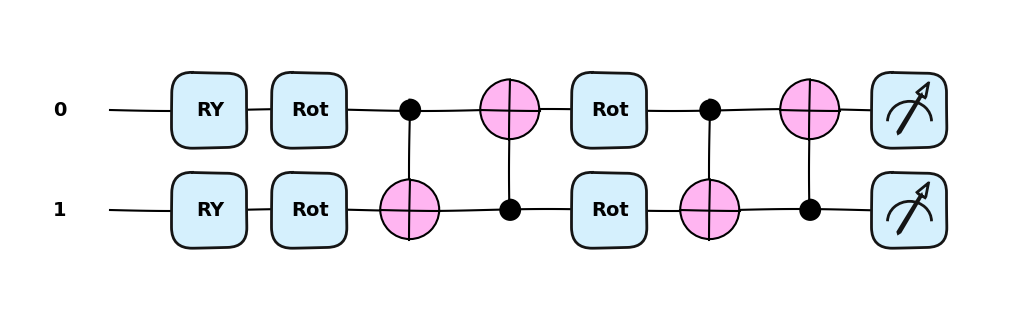

In [7]:
# Quantum circuit represented by Pennylane
qml.drawer.use_style("pennylane_sketch")
circuit = qml.draw_mpl(regressor, level=2)(X[0], weights)

In [8]:
print(qml.draw(regressor, level="device")(X[0], weights))

0: ──RY(0.00)──Rot(0.05,-0.04,-0.09)─╭●─╭X──Rot(-0.15,0.13,0.13)─╭●─╭X─┤ ╭<𝓗(1.00,0.50)>
1: ──RY(0.00)──Rot(0.22,0.21,-0.00)──╰X─╰●──Rot(0.06,-0.15,0.14)─╰X─╰●─┤ ╰<𝓗(1.00,0.50)>


In [9]:
# =====================================================
# Loss Function
# =====================================================

def cost(weights):

    loss = 0

    for x, y in zip(X, Y):

        prediction = regressor(x, weights)

        loss += (prediction - y)**2

    return loss / len(X)
# =====================================================

In [10]:
# =====================================================
# Optimizer
# =====================================================

opt = qml.AdamOptimizer(0.05)

In [11]:
steps = 100

# =====================================================
# Training Loop
# =====================================================
for step in range(steps):

    weights = opt.step(cost, weights)

    if step % 10 == 0:
        print(
            f"Step {step}: Loss = {cost(weights):.6f}"
        )

Step 0: Loss = 0.530226
Step 10: Loss = 0.164264
Step 20: Loss = 0.028150
Step 30: Loss = 0.007922
Step 40: Loss = 0.003927
Step 50: Loss = 0.001623
Step 60: Loss = 0.000617
Step 70: Loss = 0.000261
Step 80: Loss = 0.000039
Step 90: Loss = 0.000005


In [12]:
print("Trained Weights in radians: \n")
print(weights)

Trained Weights in radians: 

[[[ 0.0711158   0.00339262 -0.90325515]
  [ 0.10981663  1.55858457  0.08751777]]

 [[-0.05682266 -0.78685734  0.23082994]
  [-0.0076124  -1.34548188  0.14357459]]]


In [13]:
print("Final Quantum Regressor:\n")
print(qml.draw(regressor, level="device")(X[19], weights))

Final Quantum Regressor:

0: ──RY(4.49)──Rot(0.07,0.00,-0.90)─╭●─╭X──Rot(-0.06,-0.79,0.23)─╭●─╭X─┤ ╭<𝓗(1.00,0.50)>
1: ──RY(4.49)──Rot(0.11,1.56,0.09)──╰X─╰●──Rot(-0.01,-1.35,0.14)─╰X─╰●─┤ ╰<𝓗(1.00,0.50)>


In [14]:
# =====================================================
# Predictions
# =====================================================

for x in [0.2, 1.0, 2.0]:

    pred = regressor(x, weights)

    print(f"x={x:.2f}, prediction={pred:.4f}")

x=0.20, prediction=0.2009
x=1.00, prediction=0.8432
x=2.00, prediction=0.9070


In [15]:
Xtest = np.linspace(0, 4*np.pi, 20)

# =====================================================
# Generate Predictions
# =====================================================

predictions = []

for x in Xtest:
    pred = regressor(x, weights)
    predictions.append(pred)

predictions = np.array(predictions)
# =====================================================

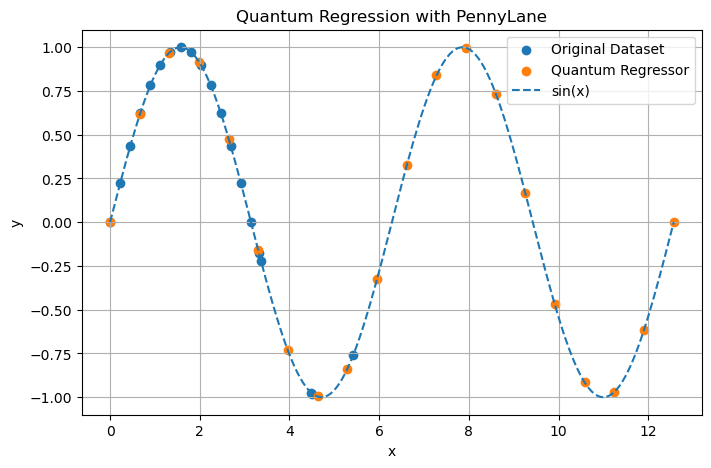

In [16]:
# =====================================================
# Plot
# =====================================================

plt.figure(figsize=(8,5))

# Original dataset
plt.scatter(
    X,
    Y,
    label="Original Dataset"
)

# Quantum regressor predictions
plt.scatter(
    Xtest,
    predictions,
    label="Quantum Regressor"
)

# True sin(x) function
x_dense = np.linspace(0, 4*np.pi, 200)
y_dense = np.sin(x_dense)

plt.plot(
    x_dense,
    y_dense,
    linestyle='dashed',
    label="sin(x)"
)

# =====================================================
# Labels
# =====================================================

plt.xlabel("x")
plt.ylabel("y")

plt.title("Quantum Regression with PennyLane")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
from platform import python_version

print('Pennylane Version:', qml.__version__)
print('Python Version:', python_version())
print('UdeA-Medellin (2026) ©')

Pennylane Version: 0.43.1
Python Version: 3.11.7
UdeA-Medellin (2026) ©
